<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Tareas 16 - mayo - 2026
</h2>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
Advección 1D
</h2>

</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Datos

N = 200
L = 1.0
v0 = 1.0

dx = L / N
x = np.linspace(0, L, N, endpoint=False)

# F. para simular advección

def adveccion_1D(CFL=0.4, pasos=200, condicion_inicial="senoidal"):
    
    dt = CFL * dx / v0
    
    if condicion_inicial == "senoidal":
        B = np.sin(2 * np.pi * x / L)
        
    elif condicion_inicial == "gaussiana":
        x0 = 0.5
        sigma = 0.06
        B = np.exp(-((x - x0)**2) / (2 * sigma**2))
        
    B_inicial = B.copy()
    
    for _ in range(pasos):
        backward = B - np.roll(B, 1)
        B += -CFL * backward
        
    return B_inicial, B, dt

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
1. ¿Cómo es el perfil de la onda?
</h3>

<p>
El perfil inicial es una onda senoidal suave. Con el método de diferencia hacia atrás, la onda se desplaza por el dominio manteniendo su forma general, pero puede perder amplitud ligeramente por difusión numérica.
</p>

</div>

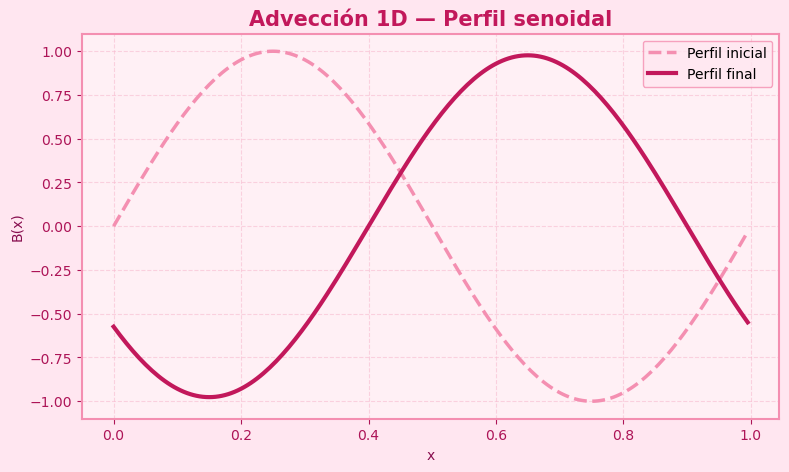

In [3]:
B0, B_final, dt = adveccion_1D(CFL=0.4, pasos=200, condicion_inicial="senoidal")

plt.figure(figsize=(9,5), facecolor="#ffe6f0")

plt.plot(x, B0, "--", color="#f48fb1", linewidth=2.5, label="Perfil inicial")
plt.plot(x, B_final, color="#c2185b", linewidth=3, label="Perfil final")

plt.title("Advección 1D — Perfil senoidal", color="#c2185b", fontsize=15, weight="bold")
plt.xlabel("x", color="#880e4f")
plt.ylabel("B(x)", color="#880e4f")

ax = plt.gca()
ax.set_facecolor("#fff0f5")
ax.tick_params(colors="#ad1457")

for spine in ax.spines.values():
    spine.set_color("#f48fb1")
    spine.set_linewidth(1.5)

plt.grid(color="#f8bbd0", linestyle="--", alpha=0.6)
plt.legend(facecolor="#ffe6f0", edgecolor="#f48fb1")
plt.show()

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
2. ¿Qué pasa si CFL es cercano a cero o cercano a 1?
</h3>

<p>
Si CFL es muy pequeño, el avance temporal es muy lento y la onda cambia poco por iteración.
</p>

<p>
Si CFL se acerca a 1, el transporte es más rápido y la onda se desplaza mejor, aunque el método sigue siendo estable mientras CFL ≤ 1.
</p>

</div>

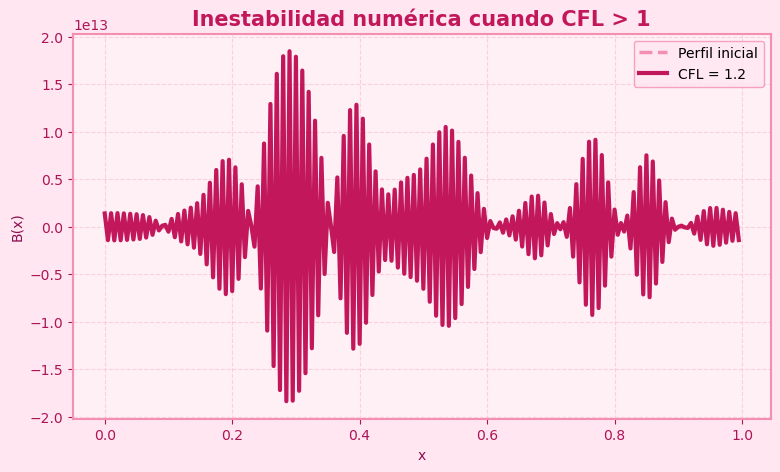

In [5]:
B0, B_final, dt = adveccion_1D(CFL=1.2, pasos=200, condicion_inicial="senoidal")

plt.figure(figsize=(9,5), facecolor="#ffe6f0")

plt.plot(x, B0, "--", color="#f48fb1", linewidth=2.5, label="Perfil inicial")
plt.plot(x, B_final, color="#c2185b", linewidth=3, label="CFL = 1.2")

plt.title("Inestabilidad numérica cuando CFL > 1", color="#c2185b", fontsize=15, weight="bold")
plt.xlabel("x", color="#880e4f")
plt.ylabel("B(x)", color="#880e4f")

ax = plt.gca()
ax.set_facecolor("#fff0f5")
ax.tick_params(colors="#ad1457")

for spine in ax.spines.values():
    spine.set_color("#f48fb1")
    spine.set_linewidth(1.5)

plt.grid(color="#f8bbd0", linestyle="--", alpha=0.6)
plt.legend(facecolor="#ffe6f0", edgecolor="#f48fb1")
plt.show()

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
3. ¿Qué pasa cuando CFL &gt; 1?
</h3>

<p>
Cuando CFL &gt; 1, el método se vuelve inestable y comienzan a aparecer oscilaciones no físicas en la solución.
</p>

<p>
La amplitud de la onda puede crecer artificialmente hasta que la simulación diverge completamente. Esto ocurre porque se viola la condición de estabilidad numérica del esquema explícito.
</p>

</div>

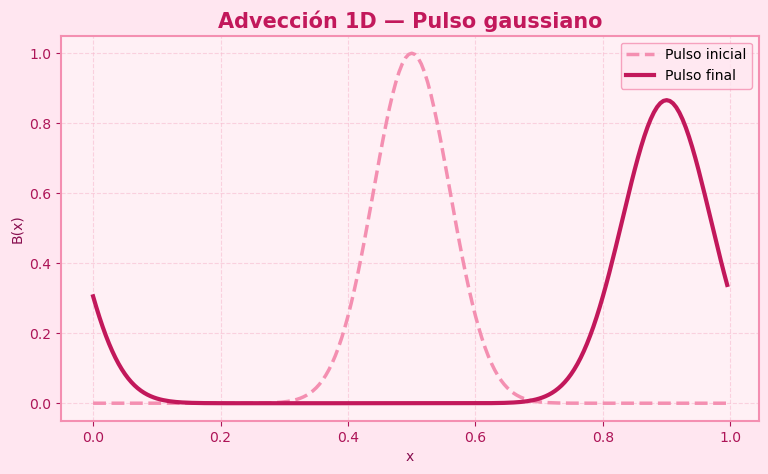

In [8]:
B0, B_final, dt = adveccion_1D(CFL=0.4, pasos=200, condicion_inicial="gaussiana")

plt.figure(figsize=(9,5), facecolor="#ffe6f0")

plt.plot(x, B0, "--", color="#f48fb1", linewidth=2.5, label="Pulso inicial")
plt.plot(x, B_final, color="#c2185b", linewidth=3, label="Pulso final")

plt.title("Advección 1D — Pulso gaussiano", color="#c2185b", fontsize=15, weight="bold")
plt.xlabel("x", color="#880e4f")
plt.ylabel("B(x)", color="#880e4f")

ax = plt.gca()
ax.set_facecolor("#fff0f5")
ax.tick_params(colors="#ad1457")

for spine in ax.spines.values():
    spine.set_color("#f48fb1")
    spine.set_linewidth(1.5)

plt.grid(color="#f8bbd0", linestyle="--", alpha=0.6)
plt.legend(facecolor="#ffe6f0", edgecolor="#f48fb1")
plt.show()

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
4. ¿Qué cambia si usamos un pulso gaussiano?
</h3>

<p>
Con un pulso gaussiano, el perfil también se desplaza, pero se nota más la difusión numérica: el pico puede disminuir y el pulso puede ensancharse.
</p>

<p>
Es decir, el método no solo transporta la señal, también la suaviza un poquito.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:34px;
">
FEM para la ecuación de Poisson gravitacional
</h2>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
Paso 1. Resolver la ecuación
</h3>

</div>

Solución de la ecuación de Poisson
Phi(0) = -6.849217e+12
Phi(R) = -4.451991e+12


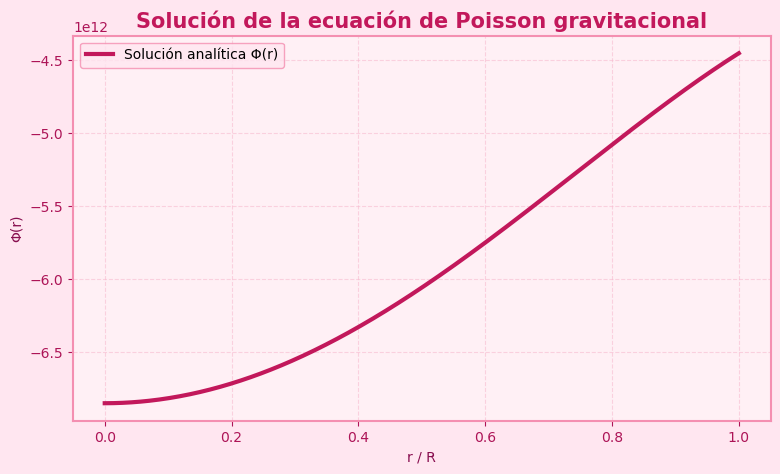

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# datos

G = 6.674e-11          # constante g  
rho_c = 1e5           # densidad central 
R = 7e8               # radio 


# densidad
def rho(r):
    return rho_c * (1 - (r/R)**2)


# sol analítica de Phi(r)


def Phi(r):
    return -2*np.pi*G*rho_c * (
        R**2/3 - r**2/6 + r**4/(20*R**2)
    )

r = np.linspace(0, R, 500)
phi = Phi(r)



print("Solución de la ecuación de Poisson")
print(f"Phi(0) = {Phi(0):.6e}")
print(f"Phi(R) = {Phi(R):.6e}")



plt.figure(figsize=(9,5), facecolor="#ffe6f0")

plt.plot(
    r/R,
    phi,
    color="#c2185b",
    linewidth=3,
    label="Solución analítica Φ(r)"
)

plt.title(
    "Solución de la ecuación de Poisson gravitacional",
    color="#c2185b",
    fontsize=15,
    weight="bold"
)

plt.xlabel("r / R", color="#880e4f")
plt.ylabel("Φ(r)", color="#880e4f")

ax = plt.gca()
ax.set_facecolor("#fff0f5")
ax.tick_params(colors="#ad1457")

for spine in ax.spines.values():
    spine.set_color("#f48fb1")
    spine.set_linewidth(1.5)

plt.grid(color="#f8bbd0", linestyle="--", alpha=0.6)

plt.legend(
    facecolor="#ffe6f0",
    edgecolor="#f48fb1"
)

plt.show()

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
Punto 1 — Reformulación
</h3>

<p>
Partimos de la ecuación de Poisson gravitacional en simetría esférica:
</p>

$$
\frac{1}{r^2}\frac{d}{dr}\left(r^2\frac{d\Phi}{dr}\right)=4\pi G\rho(r)
$$

<p>
donde la densidad está dada por:
</p>

$$
\rho(r)=\rho_c\left(1-\frac{r^2}{R^2}\right)
$$

<p>
Lo primero que hacemos es multiplicar toda la ecuación por \(r^2\) para quitar esa división incómoda:
</p>

$$
\frac{d}{dr}\left(r^2\frac{d\Phi}{dr}\right)=4\pi G r^2\rho(r)
$$

<p>
Después aparece la magia del FEM. En vez de resolver directamente la ecuación diferencial, la convertimos en una forma integral usando una función de prueba \(v(r)\).
</p>

<p>
Entonces multiplicamos todo por \(v(r)\) e integramos:
</p>

$$
\int_0^R v(r)\frac{d}{dr}\left(r^2\frac{d\Phi}{dr}\right)dr
=
\int_0^R 4\pi G r^2\rho(r)v(r)dr
$$

<p>
Ahora aplicamos integración por partes al lado izquierdo para bajar el orden de la derivada. Básicamente FEM odia derivadas muy altas JAJA.
</p>

<p>
Queda:
</p>

$$
\left[v(r)r^2\frac{d\Phi}{dr}\right]_0^R
-
\int_0^R r^2\frac{d\Phi}{dr}\frac{dv}{dr}dr
=
\int_0^R 4\pi G r^2\rho(r)v(r)dr
$$

<p>
Asumiendo que el término de borde desaparece por las condiciones de frontera, finalmente obtenemos la forma débil:
</p>

$$
\int_0^R r^2\frac{d\Phi}{dr}\frac{dv}{dr}dr
=
-\int_0^R 4\pi G r^2\rho(r)v(r)dr
$$

<p>
y reemplazando la densidad:
</p>

$$
\int_0^R r^2\frac{d\Phi}{dr}\frac{dv}{dr}dr
=
-\int_0^R 4\pi G r^2\rho_c
\left(1-\frac{r^2}{R^2}\right)v(r)dr
$$

<p>
En resumen: literalmente agarramos la ecuación diferencial original y la transformamos en una ecuación integral que sí podemos discretizar con elementos finitos. Ahí es donde después aparecen las matrices del FEM y toda la parte numérica bonita.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
n (elementos) = 10, 20, 40
</h3>

</div>

In [12]:
import numpy as np


G = 6.674e-11
rho_c = 1e5
R = 7e8


#den

def rho(r):
    return rho_c * (1 - (r/R)**2)

# FEM 1D

def FEM_poisson(n):

    # Malla
    r = np.linspace(0, R, n+1)

    h = r[1] - r[0]

    # Matriz global
    K = np.zeros((n+1, n+1))

    # Vector global
    F = np.zeros(n+1)

    for e in range(n):

        rm = 0.5 * (r[e] + r[e+1])

        # Matriz elemental
        Ke = (rm**2 / h) * np.array([
            [1, -1],
            [-1, 1]
        ])

        # Vector elemental
        Fe = -4*np.pi*G*rm**2 * rho(rm) * h/2 * np.array([1,1])

        # Ensamblaje global
        K[e:e+2, e:e+2] += Ke
        F[e:e+2] += Fe

    K[-1,:] = 0
    K[:,-1] = 0
    K[-1,-1] = 1

    F[-1] = 0

    Phi = np.linalg.solve(K, F)

    return r, Phi

# resolver para n , valor n (el profe nos lo dio)

for n in [10, 20, 40]:

    r, Phi = FEM_poisson(n)

    print(f"\nResultados para n = {n}")
    print(f"Phi(0) = {Phi[0]:.6e}")
    print(f"Phi(R) = {Phi[-1]:.6e}")


Resultados para n = 10
Phi(0) = -5.029040e+12
Phi(R) = 0.000000e+00

Resultados para n = 20
Phi(0) = -4.864859e+12
Phi(R) = 0.000000e+00

Resultados para n = 40
Phi(0) = -4.815013e+12
Phi(R) = 0.000000e+00


<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<p>
Lo que hace el código es dividir el dominio radial de la estrella en pequeños elementos lineales y aproximar el potencial gravitacional dentro de cada uno.
</p>

<p>
Después se ensamblan todas las contribuciones locales para construir el sistema global que describe toda la estrella.
</p>

<p>
Finalmente se resuelve el sistema para distintos tamaños de malla (\(n=10,20,40\)) y así observar cómo cambia la aproximación numérica.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:30px;
">
Comparar FEM vs solución analítica
</h3>

</div>

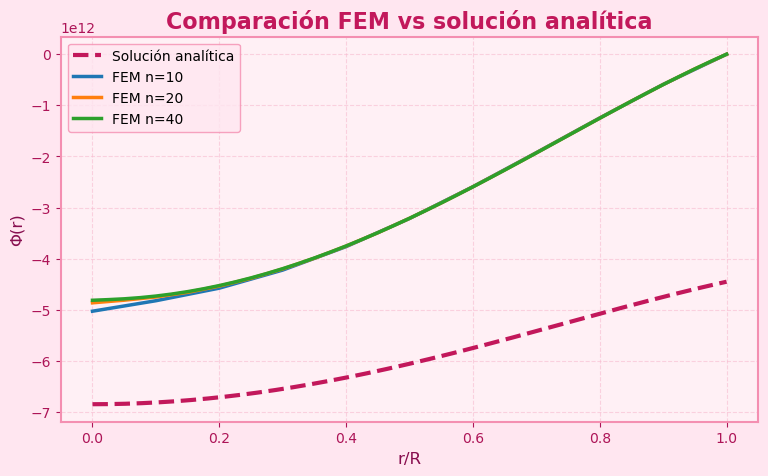

In [15]:
import numpy as np
import matplotlib.pyplot as plt


G = 6.674e-11
rho_c = 1e5
R = 7e8


def rho(r):
    return rho_c * (1 - (r/R)**2)

def phi_analitica(r):

    return -2*np.pi*G*rho_c * (
        R**2/3
        - r**2/6
        + r**4/(20*R**2)
    )
# FEM


def FEM_poisson(n):

    r = np.linspace(0, R, n+1)

    h = r[1] - r[0]

    K = np.zeros((n+1, n+1))
    F = np.zeros(n+1)

    for e in range(n):

        rm = 0.5*(r[e] + r[e+1])

        Ke = (rm**2 / h) * np.array([
            [1, -1],
            [-1, 1]
        ])

        Fe = -4*np.pi*G*rm**2 * rho(rm) * h/2 * np.array([1,1])

        K[e:e+2, e:e+2] += Ke
        F[e:e+2] += Fe

    K[-1,:] = 0
    K[:,-1] = 0
    K[-1,-1] = 1

    F[-1] = 0

    Phi = np.linalg.solve(K, F)

    return r, Phi

#gra

plt.figure(figsize=(9,5), facecolor="#ffe6f0")

# sol exacta
r_exact = np.linspace(0, R, 500)

plt.plot(
    r_exact/R,
    phi_analitica(r_exact),
    "--",
    color="#c2185b",
    linewidth=3,
    label="Solución analítica"
)

# sol FEM
for n in [10, 20, 40]:

    r, Phi = FEM_poisson(n)

    plt.plot(
        r/R,
        Phi,
        linewidth=2.5,
        label=f"FEM n={n}"
    )


ax = plt.gca()

ax.set_facecolor("#fff0f5")

plt.title(
    "Comparación FEM vs solución analítica",
    fontsize=16,
    color="#c2185b",
    weight="bold"
)

plt.xlabel("r/R", fontsize=12, color="#880e4f")
plt.ylabel("Φ(r)", fontsize=12, color="#880e4f")

plt.grid(color="#f8bbd0", linestyle="--", alpha=0.6)

ax.tick_params(colors="#ad1457")

for spine in ax.spines.values():
    spine.set_color("#f48fb1")
    spine.set_linewidth(1.5)

plt.legend(
    facecolor="#ffe6f0",
    edgecolor="#f48fb1"
)

plt.show()

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<p>
La comparación muestra que el método de elementos finitos sí reproduce bastante bien el comportamiento del potencial gravitacional.
</p>

<p>
Cuando usamos pocos elementos (\(n=10\)), la solución todavía se ve algo “tosca”, pero a medida que aumentamos la cantidad de elementos (\(n=20\) y \(n=40\)), la curva FEM se pega cada vez más a la solución analítica exacta.
</p>

<p>
Eso significa que el método converge correctamente y que aumentar la resolución espacial mejora la precisión de la aproximación numérica.
</p>

</div>

In [17]:


#malla más fina
n = 40

r, Phi = FEM_poisson(n)

h = r[1] - r[0]

g_superficial = -(Phi[-1] - Phi[-2]) / h

# v ref solar
g_sol = 274   

print("Gravedad superficial usando FEM")
print(f"g(R) = {g_superficial:.6e} m/s²")
print(f"g solar = {g_sol:.2f} m/s²")
print(f"Relación g(R)/g_sol = {g_superficial/g_sol:.6f}")

Gravedad superficial usando FEM
g(R) = -8.012003e+03 m/s²
g solar = 274.00 m/s²
Relación g(R)/g_sol = -29.240886


<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:20px;
line-height:1.8;
">

<p>
El resultado obtenido muestra una gravedad superficial mucho mayor que la solar.
</p>

<p>
Esto ocurre porque el modelo utiliza una densidad central extremadamente alta, lo que genera un potencial gravitacional mucho más intenso cerca de la superficie.
</p>

<p>
El signo negativo aparece porque la gravedad apunta hacia el centro de la estrella, pero físicamente lo importante es la magnitud del valor.
</p>

</div>